Importing and loading dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Running code for loading of dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/pro/dataset.csv"

df = pd.read_csv(file_path)
print(df.head())
print(df.columns)

   id  Gender        Age    Height      Weight family_history_with_overweight  \
0   0    Male  24.443011  1.699998   81.669950                            yes   
1   1  Female  18.000000  1.560000   57.000000                            yes   
2   2  Female  18.000000  1.711460   50.165754                            yes   
3   3  Female  20.952737  1.710730  131.274851                            yes   
4   4    Male  31.641081  1.914186   93.798055                            yes   

  FAVC      FCVC       NCP        CAEC SMOKE      CH2O SCC       FAF  \
0  yes  2.000000  2.983297   Sometimes    no  2.763573  no  0.000000   
1  yes  2.000000  3.000000  Frequently    no  2.000000  no  1.000000   
2  yes  1.880534  1.411685   Sometimes    no  1.910378  no  0.866045   
3  yes  3.000000  3.000000   Sometimes    no  1.674061  no  1.467863   
4  yes  2.679664  1.971472   Sometimes    no  1.979848  no  1.967973   

        TUE       CALC                 MTRANS           NObeyesdad  
0  0.976473

SOME USEFUL PLOTs😃: Obesity with weight(our base)

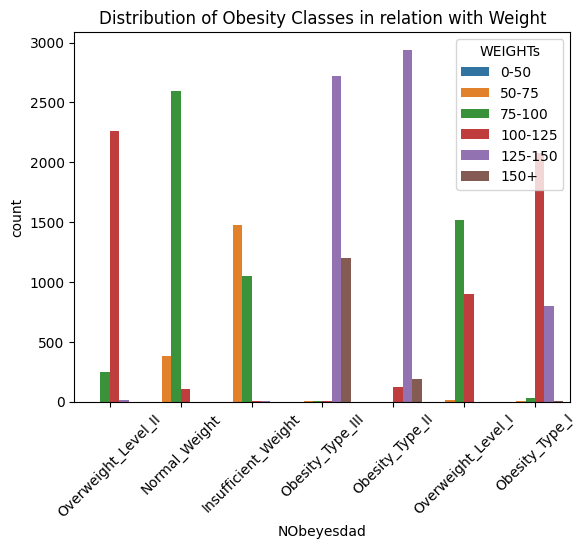

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df['WEIGHTs']=pd.cut(df['Weight'],bins=[0,25,50,75,100,125,150],labels=['0-50','50-75','75-100','100-125','125-150','150+'])
sns.countplot(x='NObeyesdad',hue='WEIGHTs', data=df)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Classes in relation with Weight')
plt.show()


Relation of age with obeseclass

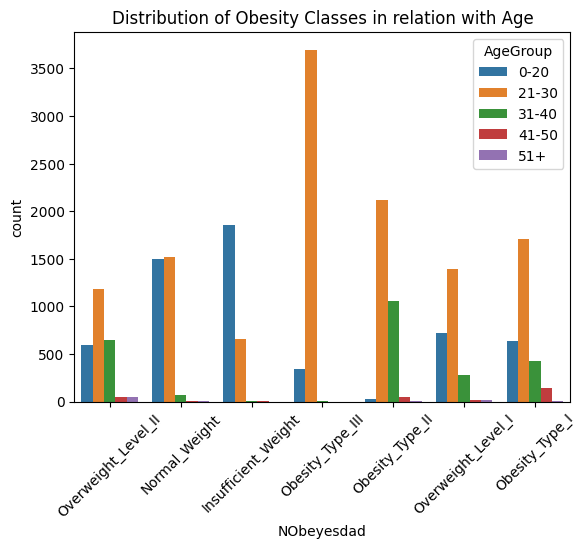

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# sns.countplot(x='NObeyesdad',hue='Age', data=df)

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 100], labels=['0-20', '21-30', '31-40', '41-50', '51+'])
sns.countplot(x='NObeyesdad',hue='AgeGroup', data=df)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Classes in relation with Age')
plt.show()

This shows us that obesity is more prominant in age group of 21-30.

Rough relation of obeseclasses with Gender

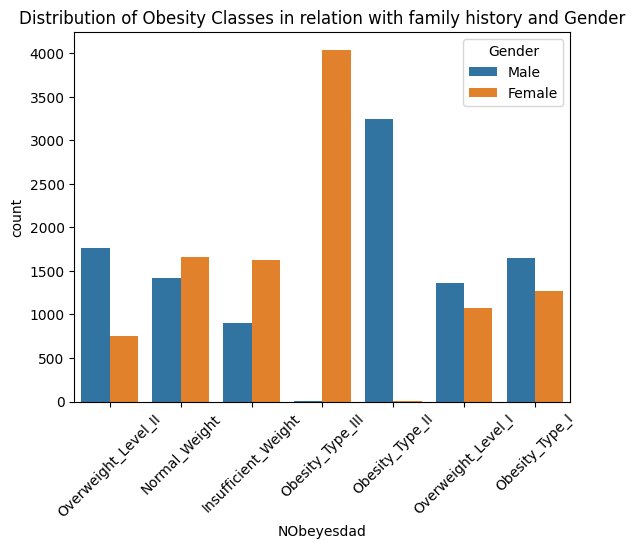

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='NObeyesdad',hue='Gender', data=df)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Classes in relation with family history and Gender')
plt.show()


A final Pairplot

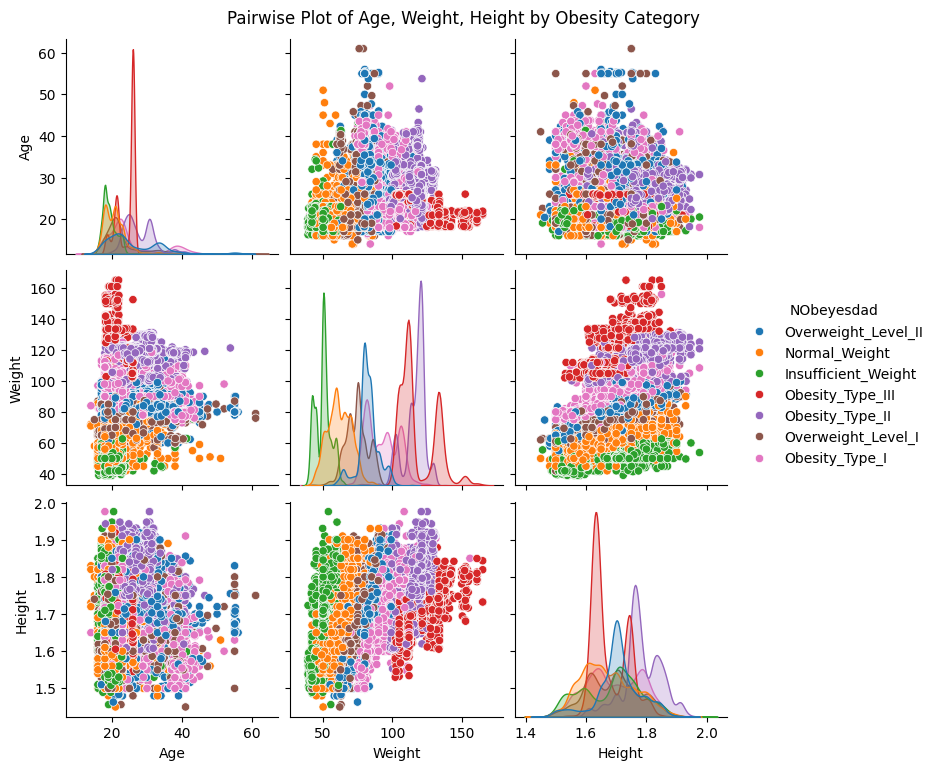

In [ ]:
sns.pairplot(df, vars=['Age', 'Weight', 'Height'], hue='NObeyesdad')
plt.suptitle('Pairwise Plot of Age, Weight, Height by Obesity Category', y=1.02)
plt.show()

Feature correlation Map Significance wrt this project ->

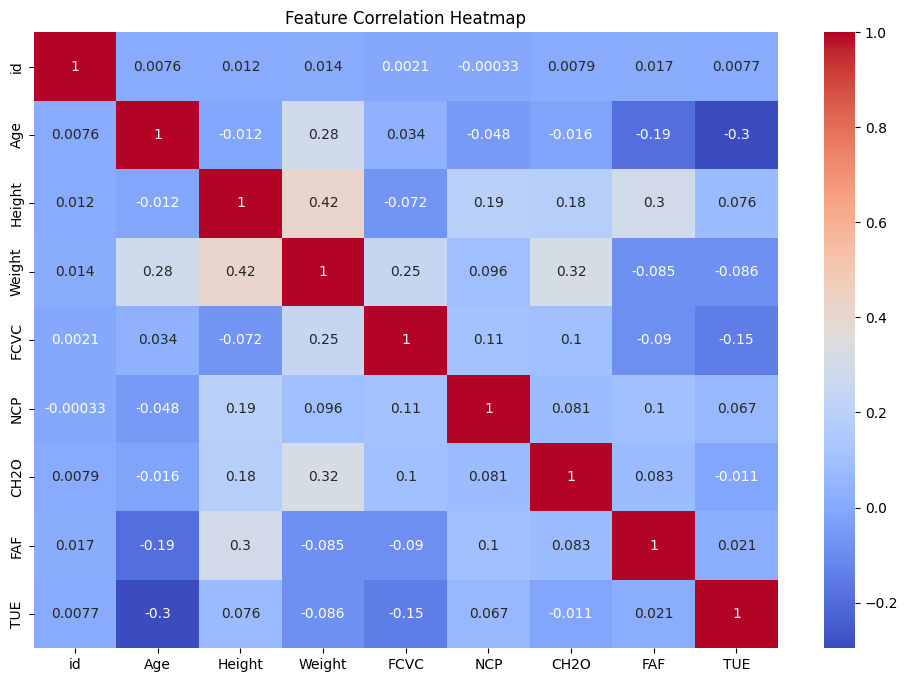

In [ ]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


IMPLEMENTING KNN CLASSIFIER :
KNN classification is my choice because it is appropriate for the data given which is in form of structural and tabular format. Since it requires multi-claasification KNN will be able to handle it appropriately.


First of all Feature scaling & One hot encoding is a must .. because dataset contain many features that are non-contiguous type(non-numeric)
And KNN relies on distance-metrics for example.

In [ ]:
#ONE HOT ENCODING
df_encoded=pd.get_dummies(df,columns=['Gender','family_history_with_overweight','FAVC','CAEC','SMOKE','SCC','CALC','MTRANS','WEIGHTs','AgeGroup'])
print(df_encoded.head())


   id        Age    Height      Weight      FCVC       NCP      CH2O  \
0   0  24.443011  1.699998   81.669950  2.000000  2.983297  2.763573   
1   1  18.000000  1.560000   57.000000  2.000000  3.000000  2.000000   
2   2  18.000000  1.711460   50.165754  1.880534  1.411685  1.910378   
3   3  20.952737  1.710730  131.274851  3.000000  3.000000  1.674061   
4   4  31.641081  1.914186   93.798055  2.679664  1.971472  1.979848   

        FAF       TUE           NObeyesdad  ...  WEIGHTs_50-75  \
0  0.000000  0.976473  Overweight_Level_II  ...          False   
1  1.000000  1.000000        Normal_Weight  ...          False   
2  0.866045  1.673584  Insufficient_Weight  ...          False   
3  1.467863  0.780199     Obesity_Type_III  ...          False   
4  1.967973  0.931721  Overweight_Level_II  ...          False   

   WEIGHTs_75-100  WEIGHTs_100-125  WEIGHTs_125-150  WEIGHTs_150+  \
0           False             True            False         False   
1            True            Fal

In [ ]:
#FEATURE SCALING (Z)-SCALE {involves use of mean and median}
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[['Age', 'Height', 'Weight']] = scaler.fit_transform(df_encoded[['Age', 'Height', 'Weight']])
print(df_encoded.head())


   id       Age    Height    Weight      FCVC       NCP      CH2O       FAF  \
0   0  0.105699 -0.002828 -0.235713  2.000000  2.983297  2.763573  0.000000   
1   1 -1.027052 -1.606291 -1.170931  2.000000  3.000000  2.000000  1.000000   
2   2 -1.027052  0.128451 -1.430012  1.880534  1.411685  1.910378  0.866045   
3   3 -0.507929  0.120090  1.644770  3.000000  3.000000  1.674061  1.467863   
4   4  1.371197  2.450367  0.224054  2.679664  1.971472  1.979848  1.967973   

        TUE           NObeyesdad  ...  WEIGHTs_50-75  WEIGHTs_75-100  \
0  0.976473  Overweight_Level_II  ...          False           False   
1  1.000000        Normal_Weight  ...          False            True   
2  1.673584  Insufficient_Weight  ...          False            True   
3  0.780199     Obesity_Type_III  ...          False           False   
4  0.931721  Overweight_Level_II  ...          False           False   

   WEIGHTs_100-125  WEIGHTs_125-150  WEIGHTs_150+  AgeGroup_0-20  \
0             True      

Is minmax scaler or Z-scale normaliser better? ->

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('NObeyesdad', axis=1)  # All features
y = df_encoded['NObeyesdad']              # Target variable

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z scale preserves outliers better than minmax scaler. Also, we have a health related dataset which is mostly non uniformly distributed that is betterly tackled by Zscale.

I m not subsampling the dataset since it already has less number of samples.

In [ ]:
#Next step is splitting data into training and testing sample.
from sklearn.model_selection import train_test_split

X = df_encoded.drop('NObeyesdad', axis=1)
y = df_encoded['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Training the model choosing a K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.1755780346820809

Confusion Matrix:
 [[106 112  74  76  95  33  28]
 [123 150  81  88 122  27  35]
 [ 88 120  85  73 106  35  36]
 [ 76  97 126 155 130  35  38]
 [106 117 146 163 193  45  34]
 [ 89 103  80  80  79  19  34]
 [ 70 100  95  95 109  24  21]]

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.16      0.20      0.18       524
      Normal_Weight       0.19      0.24      0.21       626
     Obesity_Type_I       0.12      0.16      0.14       543
    Obesity_Type_II       0.21      0.24      0.22       657
   Obesity_Type_III       0.23      0.24      0.24       804
 Overweight_Level_I       0.09      0.04      0.05       484
Overweight_Level_II       0.09      0.04      0.06       514

           accuracy                           0.18      4152
          macro avg       0.16      0.16      0.16      4152
       weighted avg       0.16      0.18      0.17      4152



Accuracy is pretty low.

In [ ]:
df['NObeyesdad'].value_counts()


,count
NObeyesdad,
Obesity_Type_III,4046
Obesity_Type_II,3248
Normal_Weight,3082
Obesity_Type_I,2910
Insufficient_Weight,2523
Overweight_Level_II,2522
Overweight_Level_I,2427


This tells us basically our data is IMBALANCED. Classes here overlap in feature space and there is a huge gap between the count of each class.This avoids KNN to implement nicely since it works on majority class concepts.

Using SMOTE (artificial balancing of set)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_balanced, y_train_balanced)


KNeighborsClassifier(n_neighbors=15)

In [ ]:
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7808285163776493
Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.76      0.81      0.79       524
      Normal_Weight       0.63      0.62      0.63       626
     Obesity_Type_I       0.76      0.72      0.74       543
    Obesity_Type_II       0.93      0.94      0.93       657
   Obesity_Type_III       1.00      0.99      1.00       804
 Overweight_Level_I       0.58      0.54      0.56       484
Overweight_Level_II       0.66      0.69      0.67       514

           accuracy                           0.78      4152
          macro avg       0.76      0.76      0.76      4152
       weighted avg       0.78      0.78      0.78      4152


Confusion Matrix:
 [[427  81   0   0   0  11   5]
 [115 391   2   0   0  94  24]
 [  4   6 389  41   2  27  74]
 [  0   2  23 618   0   1  13]
 [  0   2   0   3 799   0   0]
 [ 15 110  26   1   0 261  71]
 [  0  28  69   4   0  56 357]]


WILL IMPLEMENT LOGISTIC REGREESION NOW..

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_balanced, y_train_balanced)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_logreg = logreg.predict(X_test_scaled)

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print("Logistic Regression Accuracy:", accuracy_logreg)
print("F1 Score:", f1_logreg)
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))


Logistic Regression Accuracy: 0.8723506743737958
F1 Score: 0.8722500070932945

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.88      0.94      0.91       524
      Normal_Weight       0.87      0.78      0.82       626
     Obesity_Type_I       0.85      0.83      0.84       543
    Obesity_Type_II       0.96      0.97      0.97       657
   Obesity_Type_III       1.00      1.00      1.00       804
 Overweight_Level_I       0.71      0.75      0.73       484
Overweight_Level_II       0.74      0.75      0.74       514

           accuracy                           0.87      4152
          macro avg       0.86      0.86      0.86      4152
       weighted avg       0.87      0.87      0.87      4152



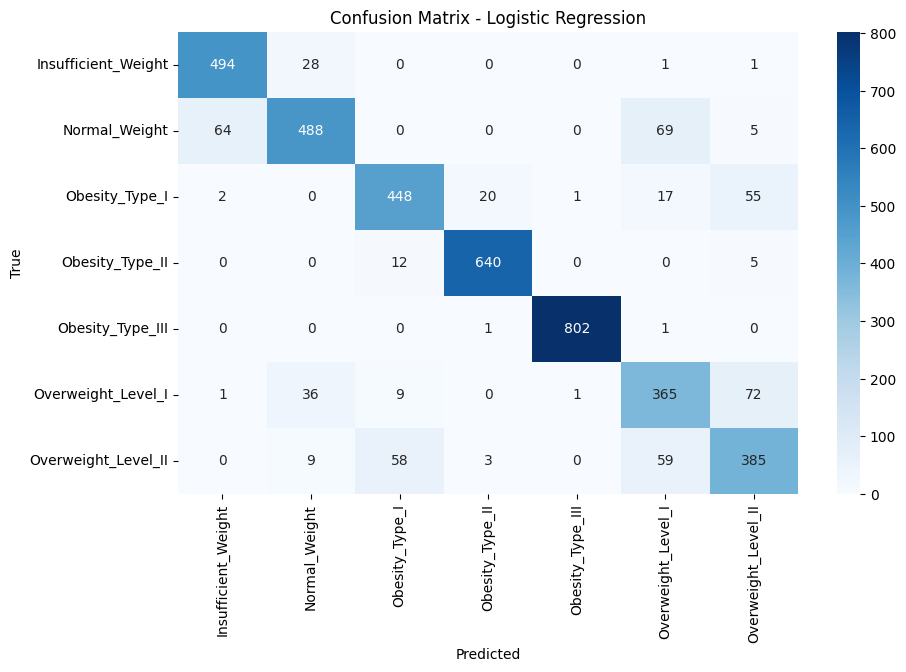

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg.classes_)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logreg.classes_, yticklabels=logreg.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Ensemble techniques implement

In [ ]:
print(y_train_balanced.value_counts())
#Basically just for checking if our dataset is balanced or not ..

NObeyesdad
Obesity_Type_I         3242
Insufficient_Weight    3242
Obesity_Type_II        3242
Overweight_Level_II    3242
Normal_Weight          3242
Obesity_Type_III       3242
Overweight_Level_I     3242
Name: count, dtype: int64


In [ ]:
#RANDOM FOREST BUILDING
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)



RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

#F1 score

f1 = f1_score(y_test, y_pred_rf, average='weighted')
print("F1 Score:", f1)


Random Forest Accuracy: 0.8935452793834296

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93       524
      Normal_Weight       0.83      0.87      0.85       626
     Obesity_Type_I       0.91      0.86      0.88       543
    Obesity_Type_II       0.98      0.97      0.98       657
   Obesity_Type_III       1.00      1.00      1.00       804
 Overweight_Level_I       0.78      0.72      0.75       484
Overweight_Level_II       0.76      0.82      0.79       514

           accuracy                           0.89      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.89      0.89      4152


Confusion Matrix:
 [[485  37   0   0   0   1   1]
 [ 33 546   1   0   0  39   7]
 [  2   1 467  11   1  11  50]
 [  0   0  13 639   0   0   5]
 [  0   0   0   1 802   0   1]
 [  1  60   7   0   0 347  69]
 [  0  13  28   2   0  47 424]]
F1 Score: 0.89356948

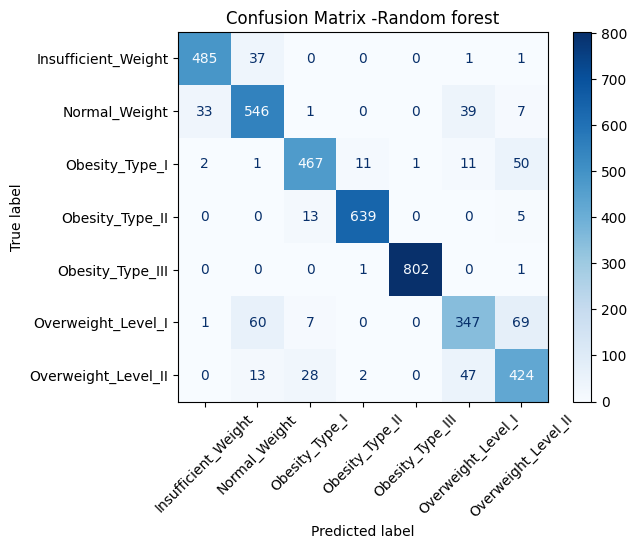

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Same thing just in plot😅
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix -Random forest")
plt.show()

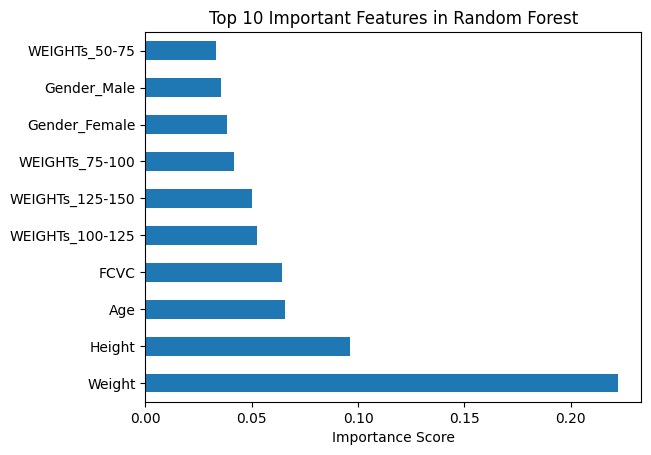

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features in Random Forest')
plt.xlabel("Importance Score")
plt.show()


What this plot basically shows is importance of each features/columns in our dataset according to which contributes lowet in impurity of trees in my RANDOM FOREST model..

Next ensemble technique is GRADIENT BOOSTING .

In [ ]:
#IMPLEMENTATION
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)


GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test_scaled)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb, average='macro'))

Accuracy: 0.9026974951830443

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.95      0.94      0.94       524
      Normal_Weight       0.87      0.89      0.88       626
     Obesity_Type_I       0.88      0.87      0.88       543
    Obesity_Type_II       0.98      0.97      0.97       657
   Obesity_Type_III       1.00      1.00      1.00       804
 Overweight_Level_I       0.79      0.78      0.79       484
Overweight_Level_II       0.78      0.81      0.79       514

           accuracy                           0.90      4152
          macro avg       0.89      0.89      0.89      4152
       weighted avg       0.90      0.90      0.90      4152


Confusion Matrix:
 [[490  31   0   0   0   2   1]
 [ 22 558   0   0   0  37   9]
 [  2   1 471  10   1  14  44]
 [  0   0  16 636   2   0   3]
 [  0   0   2   1 801   0   0]
 [  1  39   9   0   0 378  57]
 [  0  13  35   5   0  47 414]]
F1 Score: 0.8924709724264543


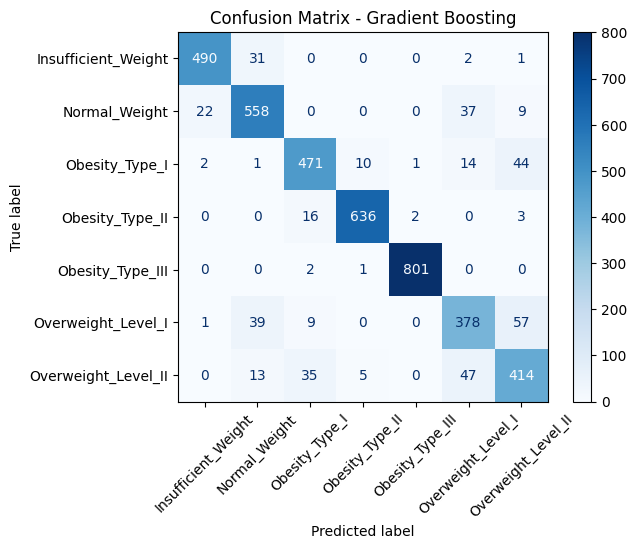

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Same thing just in plot😅
cm = confusion_matrix(y_test, y_pred_gb, labels=gb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb_model.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


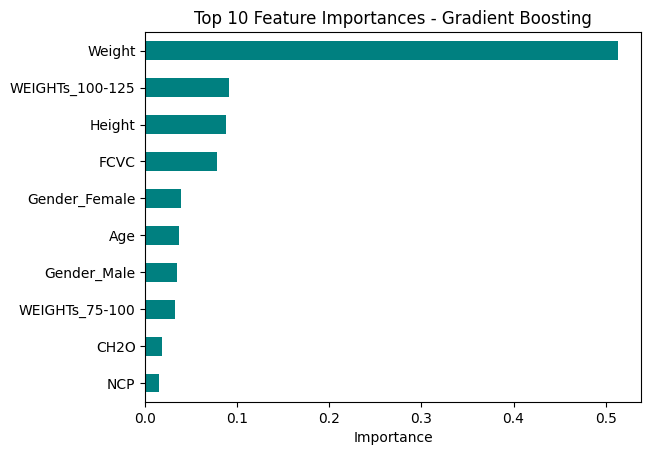

In [ ]:
import pandas as pd
import numpy as np

# Assuming X_train_balanced is a DataFrame
feature_importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
feature_importances.sort_values(ascending=False).head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


Next i m choosing Voting Classifier to combine it all..


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:

knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

In [ ]:
voting_clf = VotingClassifier(estimators=[
    ('knn', knn),
    ('rf', rf),
    ('gb', gb)
], voting='soft', weights=[1, 2, 3])  # Give more weight to stronger models

#Weighted Voting : Will choose to give weight to better performing model

In [ ]:
voting_clf.fit(X_train_balanced, y_train_balanced)
y_pred_voting = voting_clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_voting))
print("F1 Score:", f1_score(y_test, y_pred_voting, average='weighted'))
print("Report:\n", classification_report(y_test, y_pred_voting))


Accuracy: 0.9046242774566474
F1 Score: 0.9047199811413874
Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94       524
      Normal_Weight       0.87      0.89      0.88       626
     Obesity_Type_I       0.90      0.87      0.88       543
    Obesity_Type_II       0.98      0.97      0.98       657
   Obesity_Type_III       1.00      1.00      1.00       804
 Overweight_Level_I       0.80      0.76      0.78       484
Overweight_Level_II       0.78      0.83      0.80       514

           accuracy                           0.90      4152
          macro avg       0.90      0.89      0.89      4152
       weighted avg       0.91      0.90      0.90      4152



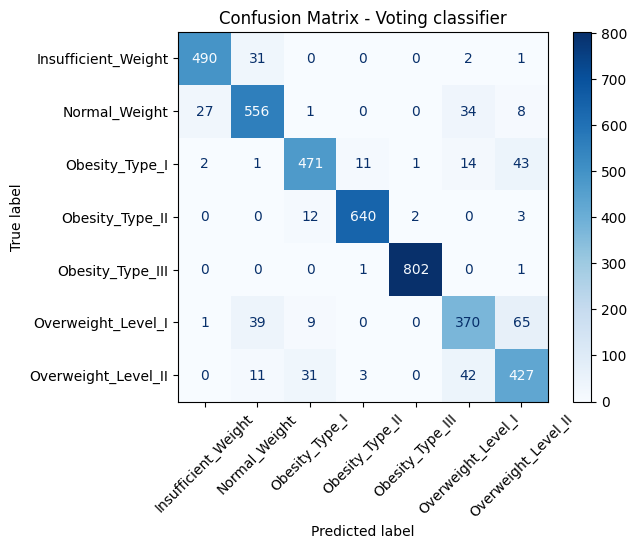

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_voting, labels=voting_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=voting_clf.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix - Voting classifier")
plt.show()

In [ ]:
results = {}
results["Voting Classifier"] = (accuracy_score(y_test, y_pred_voting), f1_score(y_test, y_pred_voting, average='weighted'))

Now comparision of all models with my BASELINE MODEL(KNN CLASSIFIER)


In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred)
f1_knn = f1_score(y_test, y_pred, average='weighted')

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

accuracy_voting = accuracy_score(y_test, y_pred_voting)
f1_voting = f1_score(y_test, y_pred_voting, average='weighted')


In [ ]:
results = {
    "KNN (Baseline)": (accuracy_knn, f1_knn),
    "Logistic Regression": (accuracy_logreg, f1_logreg),
    "Random Forest": (accuracy_rf, f1_rf),
    "Gradient Boosting": (accuracy_gb, f1_gb),
    "Voting Classifier": (accuracy_voting, f1_voting),
}


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, index=["Accuracy", "F1 Score"]).T
results_df = results_df.sort_values(by="F1 Score", ascending=False)
print(results_df)


                     Accuracy  F1 Score
Voting Classifier    0.904624  0.904720
Gradient Boosting    0.902697  0.902891
Random Forest        0.893545  0.893569
Logistic Regression  0.872351  0.872250
KNN (Baseline)       0.780829  0.779889


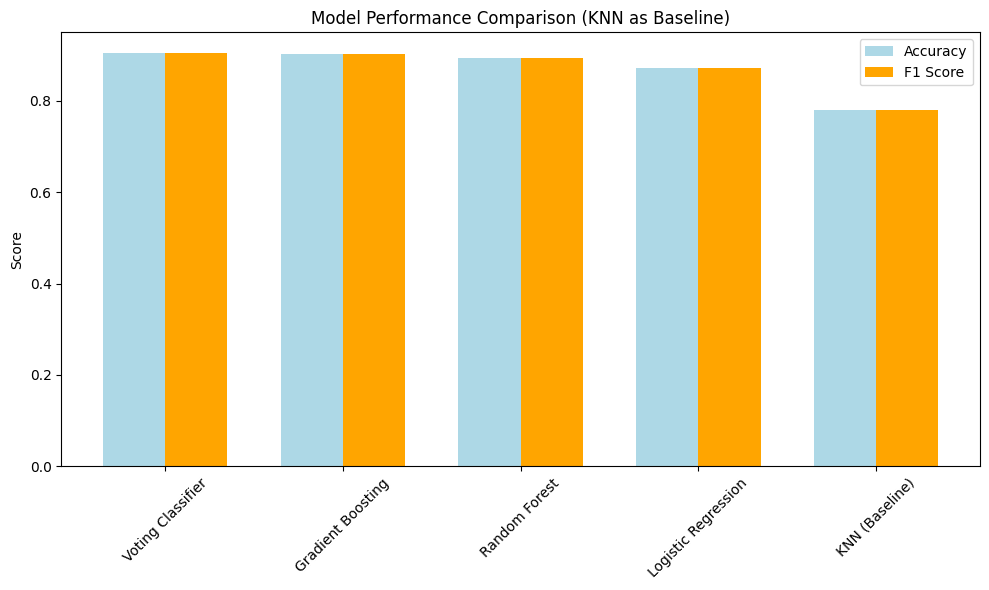

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = results_df.index
accuracy = results_df['Accuracy']
f1 = results_df['F1 Score']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, accuracy, width, label='Accuracy', color='lightblue')
plt.bar(x + width/2, f1, width, label='F1 Score', color='orange')

plt.ylabel('Score')
plt.title('Model Performance Comparison (KNN as Baseline)')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
best_model = results_df['F1 Score'].idxmax()
print(f"🏆 Best performing model based on F1 Score: {best_model}")


🏆 Best performing model based on F1 Score: Voting Classifier
